In [1]:
#Osnovne biblioteke

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter
from collections import Counter
from scipy.stats import randint
from pathlib import Path


In [2]:
#Scikit-learn – pipeline i transformacije

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    QuantileTransformer,
    FunctionTransformer,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel, SelectKBest, f_regression, mutual_info_regression

In [3]:
#Scikit-learn – modeli

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    RidgeCV,
    Lasso,
    LassoCV,
    ElasticNet
)
from sklearn.ensemble import (
    RandomForestRegressor,
    StackingRegressor
)
from sklearn.neural_network import MLPRegressor

In [4]:
#Scikit-learn – evaluacija, metrika i 

from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_squared_log_error,
    make_scorer
)
from sklearn.inspection import permutation_importance

In [5]:
#Boosting modeli

import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import category_encoders as ce

In [6]:
import warnings
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [7]:
current_directory = str(Path.cwd())
print(current_directory)

C:\Users\aleks\Sberbank\Sberbank-House-Pricing


In [8]:
data = pd.read_csv(current_directory+"/data_ceaned.csv")
df = pd.DataFrame(data)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 300)

In [9]:
df.head()

,full_sq,life_sq,floor,num_room,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,trc_sqm_500,cafe_count_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,sport_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_avg,cafe_avg_price_2000,cafe_count_2000_na_price,cafe_count_2000_price_500,cafe_count_2000_price_1000,cafe_count_2000_price_1500,cafe_count_2000_price_25

In [10]:
df.shape

(28878, 300)

In [11]:
df["sub_area_price_per_m2"] = df["sub_area"]

In [12]:
ordinal_cols = ["ecology"] 
freq_cols = ["sub_area"]
nominal_cols = ['product_type', 'culture_objects_top_25', 'thermal_power_plant_raion',
                'incineration_raion', 'oil_chemistry_raion', 'radiation_raion', 
                'railroad_terminal_raion', 'big_market_raion', 'nuclear_reactor_raion', 
                'detention_facility_raion', 'water_1line', 'big_road1_1line', 'railroad_1line']
target_cols =["price_doc", "price_doc_log","price_per_m2","log_price_per_m2"]

In [13]:
df.loc[:, "ecology"] = df["ecology"].replace("no data", np.nan)

In [14]:
def bar_plot(df, col, y_label="price_doc"):
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="black")
    plt.title(f"Distribucija {col}")
    plt.xlabel(col)
    plt.ylabel(y_label)
    plt.show()

def scatter_plot(df, col, target = "price_doc"):
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df[target], alpha=0.3)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

In [15]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        # Ako nije DataFrame, napravi ga
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts(normalize=self.normalize)
        return self

    def transform(self, X):
        # Ako nije DataFrame, napravi ga
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X
    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns)

In [16]:
# from sklearn.base import BaseEstimator, TransformerMixin

# class SubAreaTargetEncoder(BaseEstimator, TransformerMixin):
#     def __init__(self, col="sub_area"):
#         self.col = col

#     def fit(self, X, y):
#         df = X.copy()
#         df["target"] = y
#         self.mean_map_ = df.groupby(self.col)["target"].mean().to_dict()
#         self.global_mean_ = df["target"].mean()
#         return self

#     def transform(self, X):
#         X = X.copy()
#         X[self.col + "_enc"] = X[self.col].map(self.mean_map_)
#         X[self.col + "_enc"].fillna(self.global_mean_, inplace=True)
#         return X.drop(columns=[self.col])


In [17]:
def create_preprocessor(nominal_cols, ordinal_cols, freq_cols, numeric_cols, sub_area_col="sub_area_price_per_m2"):
    transformers = [
        ("nominal", 
         Pipeline([
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
         ]), 
         nominal_cols),
        
        ("ordinal", 
         Pipeline([
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("ord", OrdinalEncoder(categories=[["excellent", "good", "satisfactory", "poor"]]))
         ]), 
         ordinal_cols),
        
        ("freq", 
         Pipeline([
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("freq", FrequencyEncoder(columns=freq_cols))
         ]), 
         freq_cols),
        
        ("num", 
         Pipeline([
             ("imputer", SimpleImputer(strategy="median"))
         ]), 
         numeric_cols)
    ]


    transformers.append((
        "sub_area_enc",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("target_enc", ce.TargetEncoder())
        ]),
        [sub_area_col]
    ))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("quantile", QuantileTransformer(output_distribution="normal", random_state=42))
    ])
    
    return pipeline

In [18]:
def create_numeric_preprocessor(cols):

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("quantile", QuantileTransformer(output_distribution="normal", random_state=42))
    ])
    
    num_preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, cols)
    ])
    
    return num_preprocessor

In [19]:
def return_train_test(df_,  targets, target_col = "price_doc_log",):

    df_sorted = df_.copy()
    df_sorted["year_month"] = df_sorted["year"] * 100 + df_sorted["month"]

    df_sorted = df_sorted.sort_values("year_month")

    y = df_sorted[target_col]
    X = df_sorted.drop(columns=targets)
    
    split_idx = int(len(df_sorted) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    return X_train, X_test, y_train, y_test



In [20]:
def evaluate_regression(y_true, y_pred):
    # ako ima negativnih predikcija → postavi na 0 zbog RMSLE
    y_pred_clip = np.maximum(0, y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred_clip))

    print("MSE: ", mse)
    print("RMSE: ", rmse)
    print("MAE: ", mae)
    print("R²: ", r2)
    print("RMSLE: ", rmsle)

In [21]:
def unlog(y_log_pred):
    return np.expm1(y_log_pred)

In [22]:
X_train, X_test, y_train, y_test = return_train_test(df, target_cols)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (23102, 298)
X_test shape: (5776, 298)
y_train shape: (23102,)
y_test shape: (5776,)


In [25]:
X_train, X_test, y_train, y_test = return_train_test(df, target_cols)

num_cols = X_train.select_dtypes("number").columns.tolist()
numeric_preprocessor = create_preprocessor(nominal_cols, ordinal_cols, freq_cols, num_cols, sub_area_col="sub_area_price_per_m2")

In [26]:
# Selectuje featurse sa Lasso
pipeline_lasso = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("model", LassoCV(cv=5))
])
# SelectKBest (npr. f_regression)
pipeline_kbest = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("feature_selection", SelectKBest(score_func=f_regression, k=50)),  
    ("model", LinearRegression())
])


# SelectKBest (mutual_info_regression)
pipeline_mi = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("feature_selection", SelectKBest(score_func=mutual_info_regression, k=50)),  
    ("model", LinearRegression())
])

In [27]:
pipeline_lasso.fit(X_train, y_train)

# koeficijenti
coefs = pipeline_lasso.named_steps["model"].coef_

# imena kolona iz preprocessora
feature_names = pipeline_lasso.named_steps["preprocessor"].get_feature_names_out()

# filtriraj nenulte
selected = [f for f, c in zip(feature_names, coefs) if c != 0]
print(selected)


['nominal__product_type_OwnerOccupier', 'nominal__thermal_power_plant_raion_yes', 'nominal__railroad_terminal_raion_yes', 'nominal__big_market_raion_yes', 'nominal__detention_facility_raion_yes', 'nominal__water_1line_yes', 'nominal__big_road1_1line_yes', 'nominal__railroad_1line_yes', 'freq__sub_area', 'num__full_sq', 'num__life_sq', 'num__floor', 'num__num_room', 'num__indust_part', 'num__preschool_education_centers_raion', 'num__healthcare_centers_raion', 'num__university_top_20_raion', 'num__additional_education_raion', 'num__shopping_centers_raion', 'num__office_raion', 'num__ekder_male', 'num__build_count_frame', 'num__build_count_panel', 'num__build_count_slag', 'num__build_count_mix', 'num__build_count_before_1920', 'num__build_count_1946-1970', 'num__build_count_1971-1995', 'num__ID_metro', 'num__metro_min_avto', 'num__metro_km_avto', 'num__kindergarten_km', 'num__green_zone_km', 'num__industrial_km', 'num__water_treatment_km', 'num__ID_railroad_station_walk', 'num__railroad_s

In [ ]:
y_pred = unlog(pipeline_lasso.predict(X_test))
y_test_unlog = unlog(y_test)

evaluate_regression(y_test_unlog, y_pred)

In [28]:
pipeline_kbest.fit(X_train, y_train)
y_pred = unlog(pipeline_kbest.predict(X_test))
y_test_unlog = unlog(y_test)

evaluate_regression(y_test_unlog, y_pred)

C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


MSE:  10462754835114.182
RMSE:  3234618.1900054575
MAE:  2245681.2634103964
R²:  0.4272421714232094
RMSLE:  0.4479626266654555


In [29]:
# pipeline_mi.fit(X_train, y_train)
# y_pred = unlog(pipeline_mi.predict(X_test))
# y_test_unlog = unlog(y_test)

# evaluate_regression(y_test_unlog, y_pred)

In [30]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror", 
        n_estimators=500, 
        random_state=42,
        tree_method="hist"  
    ))
])

In [31]:
param_dist = {
    "model__max_depth": [3, 5],              
    "model__learning_rate": [0.05, 0.1],     
    "model__subsample": [0.8],              
    "model__colsample_bytree": [0.8],    
    "model__n_estimators": [100, 200],    
    "model__tree_method": ["hist"],        
    "model__n_jobs": [1],               
}

random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=4,
    cv=2,
    scoring="neg_root_mean_squared_error",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [32]:
random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)

y_pred = unlog(random_search.predict(X_test))
y_test_unlog = unlog(y_test)
evaluate_regression(y_test_unlog, y_pred)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best params: {'model__tree_method': 'hist', 'model__subsample': 0.8, 'model__n_jobs': 1, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


MSE:  6967933472250.917
RMSE:  2639684.3508743457
MAE:  1852265.1410145422
R²:  0.6185575875447321
RMSLE:  0.41778208587904064


In [33]:
# najbolji pipeline
best_pipeline = random_search.best_estimator_

# pristupi XGB modelu
xgb_model = best_pipeline.named_steps["model"]

# pristupi imenu kolona iz preprocessora
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

# importances
importances = xgb_model.feature_importances_


In [34]:
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)


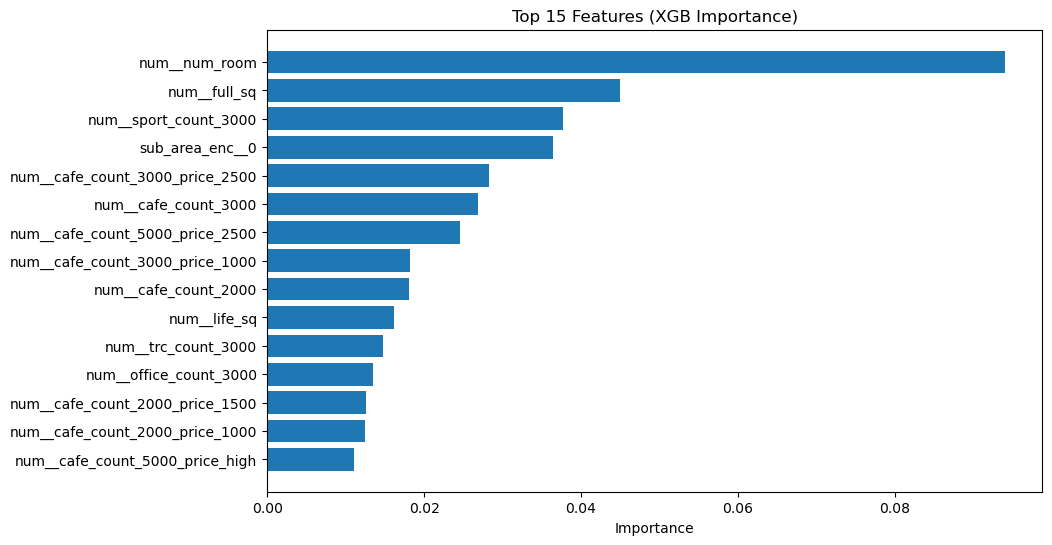

In [35]:
import matplotlib.pyplot as plt

top15 = feat_imp.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15["Feature"], top15["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Features (XGB Importance)")
plt.xlabel("Importance")
plt.show()

In [36]:
import joblib

# uzmi najbolji pipeline iz RandomizedSearchCV
best_pipeline = random_search.best_estimator_

# snimi ga u fajl
joblib.dump(best_pipeline, "xgb_best_pipeline.pkl")

['xgb_best_pipeline.pkl']

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [38]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    "model__n_estimators": [10, 20, 30],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    rf_pipeline,                                
    param_distributions=param_dist_rf,
    n_iter=4,                                   
    cv=2,                                       
    scoring="neg_root_mean_squared_error",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [39]:
# random_search.fit(X_train, y_train)

# print("Best params:", random_search.best_params_)

# y_pred = unlog(random_search.predict(X_test))
# y_test_unlog = unlog(y_test)
# evaluate_regression(y_test_unlog, y_pred)

In [40]:
from sklearn.ensemble import StackingRegressor, VotingRegressor

stack = StackingRegressor(
    estimators=[
        ("ridge", Ridge(alpha=1.0)),
        ("xgb", XGBRegressor(
            n_estimators=200,
            tree_method="hist",
            n_jobs=-1,
            objective="reg:squarederror",
            random_state=42
        )),
        ("lgbm", LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            n_jobs=-1,
            random_state=42
        ))
    ],
    final_estimator=LinearRegression(n_jobs=-1),
    n_jobs=-1
)

In [41]:
stack_pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("model", stack)
])

In [42]:
# stack_pipeline.fit(X_train, y_train)

# y_pred = unlog(stack_pipeline.predict(X_test))
# y_test_unlog = unlog(y_test)

# evaluate_regression(y_test_unlog, y_pred)